In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("placement.csv")

In [3]:
df.shape

(1000, 3)

In [5]:
df.sample(5)

,cgpa,placement_exam_marks,placed
916,6.88,11.0,1
719,7.17,26.0,0
90,7.61,15.0,1
308,7.20,47.0,1
168,6.51,37.0,1


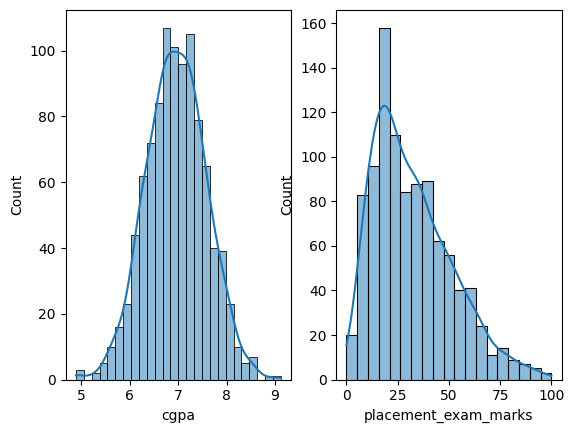

In [ ]:
plt.Figure(figsize=(10, 6))

# Plot for 'cgpa'"Outlier_Detection_Removal_Using_Z-Score Method_Placement_Data.pdf"
plt.subplot(1, 2, 1)
sns.histplot(df['cgpa'], kde=True)

# Plot for 'placement_marks' 
plt.subplot(1, 2, 2)
sns.histplot(df['placement_exam_marks'], kde=True)

plt.show()

In [10]:
print(df['cgpa'].skew()) 
# skewness of 'cgpa' column

-0.014529938929314918


In [11]:
print(df['placement_exam_marks'].skew())

0.8356419499466834


In [12]:
print("Mean value of cgpa", df['cgpa'].mean())
print("Standard Deviation of cgpa", df['cgpa'].std())
print("Min Value of cgpa", df['cgpa'].min())
print("Max Value of cgpa", df['cgpa'].max())

Mean value of cgpa 6.96124
Standard Deviation of cgpa 0.6158978751323896
Min Value of cgpa 4.89
Max Value of cgpa 9.12


In [13]:
# Boundary Values
print("Highest allowed", df['cgpa'].mean() + 3 * df['cgpa'].std())
print("Lowest allowed", df['cgpa'].mean() - 3 * df['cgpa'].std())

Highest allowed 8.808933625397168
Lowest allowed 5.113546374602832


In [14]:
# Outliers
df[(df['cgpa'] > 8.80) | (df['cgpa'] < 5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [15]:
# Trimming
df_trimmed = df[(df['cgpa'] <= 8.80) & (df['cgpa'] >= 5.11)]
df_trimmed

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


In [16]:
# Approach 2: Using Z-Score

df['cgpa_zscore'] = (df['cgpa'] - df['cgpa'].mean()) / df['cgpa'].std()

In [17]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [18]:
df[df['cgpa_zscore'] > 3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062


In [19]:
df[df['cgpa_zscore'] < -3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [20]:
df[(df['cgpa_zscore'] > 3) | (df['cgpa_zscore'] < -3)]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [21]:
# Trimming using Z-Score
new_df = df[(df['cgpa_zscore'] < 3) & (df['cgpa_zscore'] > -3)]

In [22]:
new_df

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


In [23]:
new_df.shape

(995, 4)

In [24]:
# Capping

upper_limit = df['cgpa'].mean() + 3 * df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3 * df['cgpa'].std()

In [28]:
print(upper_limit)

8.808933625397168


In [29]:
print(lower_limit)

5.113546374602832


In [30]:
df['cgpa'] = np.where(
    df['cgpa'] > upper_limit,
    upper_limit,
    np.where(
        df['cgpa'] < lower_limit,
        lower_limit,
        df['cgpa']
    )
)

In [31]:
df.shape

(1000, 4)

In [32]:
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64